# Redes neuronales densas: del perceptrón multicapa al entrenamiento con PyTorch

> Cómo funciona una red neuronal totalmente conectada: neuronas y funciones de activación, función de pérdida, descenso del gradiente, retropropagación y optimizadores (SGD, momentum, Adam). Se construye y entrena un perceptrón multicapa en PyTorch con el bucle de entrenamiento completo, y se muestran el efecto de la tasa de aprendizaje y el problema del gradiente que desaparece.
>
> **Requisitos previos:** [Flujo de ML y evaluación](../04-machine-learning/01-flujo-ml-y-evaluacion.ipynb) · **Relacionado:** [Entrenamiento y regularización](02-entrenamiento-y-regularizacion.ipynb) · [Redes convolucionales](03-redes-convolucionales.ipynb)

## 1. Idea clave

Una red neuronal densa (*fully connected*, o **perceptrón multicapa**, MLP) es una cadena de capas en las que cada neurona recibe todas las salidas de la capa anterior, las combina linealmente y aplica una **función no lineal**. Es un aproximador de funciones muy flexible: con suficientes neuronas puede representar relaciones complejas entre las variables de entrada y la salida, y se entrena de forma automática ajustando sus pesos con el **descenso del gradiente**, calculando los gradientes con **retropropagación** (*backpropagation*).

Es la base de todo el aprendizaje profundo (las [convolucionales](03-redes-convolucionales.ipynb), las [recurrentes](06-redes-recurrentes.ipynb) y los [transformers](07-atencion-y-transformers.ipynb) están hechos con capas densas y variaciones). Para **datos tabulares** compite con los [árboles y el *boosting*](../04-machine-learning/11-boosting.ipynb), que suelen ganarle con menos ajuste; para **imágenes, secuencias o texto** una red densa a secas es una mala elección (aprovecha mal la estructura de los datos) y se usan arquitecturas especializadas. Este notebook explica la mecánica que comparten todas.

## 2. Conceptos importantes

### 2.1. La neurona

Una neurona artificial calcula una combinación lineal de sus entradas $\mathbf{x}=(x_1,\dots,x_n)$ y le aplica una **función de activación** $\varphi$:

$$
z=\mathbf{w}^\top\mathbf{x}+b,\qquad a=\varphi(z),
$$

donde $\mathbf{w}$ son los **pesos** (cuánto cuenta cada entrada), $b$ el **sesgo** (*bias*, un umbral ajustable) y $a$ la salida o **activación**. Sin la función $\varphi$ sería una regresión lineal; con $\varphi$ sigmoide es una regresión logística. Una **capa** son varias neuronas que miran las mismas entradas: en forma matricial, $\mathbf{a}=\varphi(W\mathbf{x}+\mathbf{b})$.

### 2.2. Funciones de activación

| Función | Fórmula | Rango | Derivada máxima | Comentario |
|---|---|---|---|---|
| **Sigmoide** | $\sigma(z)=\dfrac{1}{1+e^{-z}}$ | $(0,1)$ | $0{,}25$ | Para probabilidades en la salida binaria; se satura en los extremos |
| **Tanh** | $\tanh(z)$ | $(-1,1)$ | $1$ | Centrada en 0; también se satura |
| **ReLU** | $\max(0,z)$ | $[0,\infty)$ | $1$ | Opción por defecto en capas ocultas: barata y no se satura en $z>0$; una neurona con $z<0$ siempre tiene gradiente 0 ("neurona muerta") |
| **Leaky ReLU** | $\max(\alpha z, z)$, con $\alpha$ pequeño | $\mathbb{R}$ | $1$ | Evita las neuronas muertas |
| **Softmax** | $\mathrm{softmax}(\mathbf{z})_k=\dfrac{e^{z_k}}{\sum_j e^{z_j}}$ | $(0,1)$, suman 1 | — | Salida de clasificación multiclase: convierte $K$ puntuaciones en probabilidades |

**Por qué hace falta la no linealidad.** Si todas las activaciones fueran lineales, la red entera sería equivalente a una sola capa: $W_2(W_1\mathbf{x}+\mathbf{b}_1)+\mathbf{b}_2=(W_2W_1)\mathbf{x}+(W_2\mathbf{b}_1+\mathbf{b}_2)$. Es la no linealidad la que permite que apilar capas dé lugar a funciones más ricas (lo comprobamos en 3.4). El **teorema de aproximación universal** dice que una sola capa oculta con suficientes neuronas y una activación no lineal puede aproximar cualquier función continua en un dominio acotado; en la práctica se prefieren varias capas, que lo consiguen con muchos menos parámetros.

### 2.3. Arquitectura y número de parámetros

Una red tiene una **capa de entrada** (los datos), una o más **capas ocultas** y una **capa de salida** (tantas neuronas como clases, o una para regresión). Una capa densa con $n_{\text{ent}}$ entradas y $n_{\text{sal}}$ neuronas tiene $n_{\text{ent}}\,n_{\text{sal}}+n_{\text{sal}}$ parámetros (pesos más sesgos). Para una imagen de $28\times28$ aplanada (784 entradas), dos capas ocultas de 128 neuronas y 10 salidas:

$$
\underbrace{784\cdot128+128}_{100\,480}+\underbrace{128\cdot128+128}_{16\,512}+\underbrace{128\cdot10+10}_{1\,290}=118\,282.
$$

Los parámetros crecen con el **producto** de los tamaños de capas consecutivas, de modo que una entrada grande (una imagen de alta resolución) encarece mucho la primera capa.

### 2.4. Función de pérdida

Mide cuánto se equivoca la red; el entrenamiento la minimiza. Para **regresión**, el error cuadrático medio $L=\frac1n\sum_i(y_i-\hat{y}_i)^2$. Para **clasificación** con $K$ clases se usa la **entropía cruzada** (*cross-entropy*) entre las etiquetas reales (one-hot, $y_k\in\{0,1\}$) y las probabilidades $p_k$ que da la softmax:

$$
L=-\sum_{k=1}^{K}y_k\log p_k=-\log p_{\text{clase correcta}}.
$$

Penaliza mucho asignar poca probabilidad a la clase correcta (si $p=0{,}01$, $L\approx4{,}6$) y su gradiente respecto a la puntuación $z_k$ es simplemente $p_k-y_k$, que no se anula cuando la red se equivoca con seguridad (con el error cuadrático sí ocurriría).

### 2.5. Descenso del gradiente

Para minimizar $L(\theta)$ (con $\theta$ todos los pesos y sesgos), se repite

$$
\theta\leftarrow\theta-\eta\,\nabla_\theta L,
$$

dando un paso en la dirección opuesta al gradiente, de longitud proporcional a la **tasa de aprendizaje** (*learning rate*) $\eta$. Calcular el gradiente con todos los datos en cada paso es caro, así que se usa el **descenso del gradiente por mini-lotes** (*mini-batch*): en cada paso se estima el gradiente con un lote de $B$ ejemplos (típicamente 32–256). Una **época** es una pasada completa por los datos y una **iteración**, un paso (con $N$ ejemplos hay $N/B$ iteraciones por época). El ruido de usar lotes pequeños ayuda a no quedar atrapado en malos mínimos.

### 2.6. Retropropagación

El gradiente de $L$ respecto a cada peso se calcula con la **regla de la cadena**. Primero, la **pasada hacia delante** (*forward*) calcula y guarda las activaciones de cada capa hasta la pérdida; después, la **pasada hacia atrás** propaga el error desde la salida: con $\boldsymbol{\delta}^{(l)}=\partial L/\partial\mathbf{z}^{(l)}$ el error de la capa $l$,

$$
\boldsymbol{\delta}^{(l)}=\big(W^{(l+1)\top}\boldsymbol{\delta}^{(l+1)}\big)\odot\varphi'\big(\mathbf{z}^{(l)}\big),
\qquad
\frac{\partial L}{\partial W^{(l)}}=\boldsymbol{\delta}^{(l)}\,\mathbf{a}^{(l-1)\top},
\qquad
\frac{\partial L}{\partial \mathbf{b}^{(l)}}=\boldsymbol{\delta}^{(l)},
$$

con $\odot$ el producto elemento a elemento. Calcular todos los gradientes cuesta del orden de dos pasadas hacia delante, no una por parámetro. PyTorch lo hace solo (**autograd**): construye un grafo con las operaciones de la pasada hacia delante y `loss.backward()` lo recorre hacia atrás. En 3.2 lo comprobamos a mano.

### 2.7. El gradiente que desaparece

En $\boldsymbol{\delta}^{(l)}$ aparece $\varphi'(\mathbf{z})$ en cada capa. Propagar el error por $L$ capas multiplica $L$ derivadas. Con la sigmoide ($\varphi'\le0{,}25$) el gradiente se **reduce exponencialmente** al retroceder: las primeras capas casi no reciben señal y aprenden muy despacio (**desaparición del gradiente**, *vanishing gradient*; lo contrario, que crezca sin control, es la **explosión del gradiente**). Se mitiga con activaciones no saturantes (ReLU), una inicialización adecuada de los pesos, normalización de capas y conexiones residuales ([arquitecturas profundas](04-transfer-learning.ipynb)).

### 2.8. Optimizadores

- **SGD** (*stochastic gradient descent*): $\theta\leftarrow\theta-\eta g$, con $g$ el gradiente del lote.
- **SGD con momento**: acumula una "velocidad" $v\leftarrow\beta v+g$, $\theta\leftarrow\theta-\eta v$ (con $\beta\approx0{,}9$). Suaviza el ruido y acelera en direcciones consistentes.
- **Adam**: adapta la tasa **de cada parámetro** usando medias móviles del gradiente $m$ y de su cuadrado $v$: $\theta\leftarrow\theta-\eta\,\hat m/(\sqrt{\hat v}+\epsilon)$, con $\hat m,\hat v$ corregidos por sesgo. Valores por defecto: $\beta_1=0{,}9$, $\beta_2=0{,}999$, $\epsilon=10^{-8}$, $\eta=10^{-3}$. Es la opción por defecto: funciona bien con poco ajuste.

### 2.9. Inicialización

Los pesos se inicializan al azar con valores pequeños: si todos fueran iguales (por ejemplo, cero), todas las neuronas de una capa harían lo mismo y recibirían el mismo gradiente (**simetría**). Las reglas de **Xavier/Glorot** (para tanh y sigmoide) y de **He** (para ReLU) escalan la varianza inicial según el número de entradas para que las activaciones y los gradientes no crezcan ni decrezcan al atravesar las capas. Las capas de PyTorch ya traen una inicialización razonable.

## 3. Código

Usamos **Fashion-MNIST**: 70 000 imágenes en escala de grises de $28\times28$ píxeles de 10 tipos de prendas y calzado (60 000 para entrenamiento y 10 000 para test), publicadas por Zalando Research. Cada imagen se aplana a un vector de 784 valores y se **estandariza** con la media y la desviación típica del entrenamiento (véase [escalado](../03-preparacion-datos/03-transformacion-datos.ipynb)). Separamos 10 000 imágenes de validación del entrenamiento para decidir, y reservamos el test para evaluar una sola vez. Es un conjunto de referencia sencillo; las imágenes ya vienen centradas y a tamaño fijo.

Si hay GPU, PyTorch la usa (`device`); el código funciona igual en CPU. Las cifras pueden variar ligeramente entre dispositivos.

In [1]:
import contextlib
import io

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets

torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Dispositivo:", device)

Dispositivo: cuda


### 3.1. Datos

entrenamiento (50000, 784), validación (10000, 784), test (10000, 784)
media 0.286, desviación 0.353


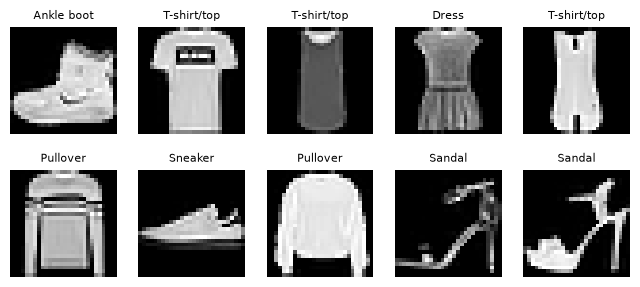

In [2]:
with contextlib.redirect_stderr(io.StringIO()):          # silencia las barras de descarga
    entrenamiento = datasets.FashionMNIST("data", train=True, download=True)
    prueba = datasets.FashionMNIST("data", train=False, download=True)
clases = entrenamiento.classes

X = entrenamiento.data.float().div(255).view(-1, 784)
y = entrenamiento.targets
media, desv = X.mean(), X.std()
X = (X - media) / desv
X_test = (prueba.data.float().div(255).view(-1, 784) - media) / desv
y_test = prueba.targets

orden = torch.randperm(len(X), generator=torch.Generator().manual_seed(42))
X_train, y_train = X[orden[:50000]], y[orden[:50000]]
X_val, y_val = X[orden[50000:]], y[orden[50000:]]
print(f"entrenamiento {tuple(X_train.shape)}, validación {tuple(X_val.shape)}, test {tuple(X_test.shape)}")
print(f"media {media:.3f}, desviación {desv:.3f}")

fig, axes = plt.subplots(2, 5, figsize=(8, 3.4))
for ax, i in zip(axes.ravel(), range(10)):
    ax.imshow(entrenamiento.data[i], cmap="gray")
    ax.set_title(clases[entrenamiento.targets[i]], fontsize=8)
    ax.axis("off")
plt.show()

### 3.2. Retropropagación a mano frente a autograd

Para ver que no hay magia, una red minúscula (3 entradas, 4 neuronas ocultas con ReLU, 1 salida, error cuadrático) con un único ejemplo. Calculamos los gradientes con las fórmulas de 2.6 y los comparamos con los que da `loss.backward()`.

In [3]:
torch.manual_seed(0)
x = torch.tensor([0.5, -1.0, 2.0])
objetivo = torch.tensor(1.5)
W1 = torch.randn(4, 3, requires_grad=True); b1 = torch.randn(4, requires_grad=True)
W2 = torch.randn(1, 4, requires_grad=True); b2 = torch.randn(1, requires_grad=True)

# Pasada hacia delante
z1 = W1 @ x + b1
a1 = torch.relu(z1)
y_hat = (W2 @ a1 + b2).squeeze()
perdida = (y_hat - objetivo) ** 2
perdida.backward()                                    # autograd

# A mano: regla de la cadena (sin usar los .grad)
with torch.no_grad():
    delta2 = 2 * (y_hat - objetivo)                   # dL/dz2 (la salida es lineal)
    grad_W2 = delta2 * a1.unsqueeze(0)                # dL/dW2 = δ2 · a1ᵀ
    grad_b2 = delta2.unsqueeze(0)
    delta1 = (W2.T.squeeze() * delta2) * (z1 > 0).float()   # δ1 = (W2ᵀ δ2) ⊙ ReLU'(z1)
    grad_W1 = torch.outer(delta1, x)                  # dL/dW1 = δ1 · xᵀ
    grad_b1 = delta1

for nombre, a_mano, auto in [("W1", grad_W1, W1.grad), ("b1", grad_b1, b1.grad), ("W2", grad_W2, W2.grad), ("b2", grad_b2, b2.grad)]:
    print(f"{nombre}: máxima diferencia entre el cálculo a mano y autograd = {(a_mano - auto).abs().max():.1e}")

W1: máxima diferencia entre el cálculo a mano y autograd = 0.0e+00
b1: máxima diferencia entre el cálculo a mano y autograd = 0.0e+00
W2: máxima diferencia entre el cálculo a mano y autograd = 0.0e+00
b2: máxima diferencia entre el cálculo a mano y autograd = 0.0e+00


Coinciden (la diferencia es exactamente 0 en coma flotante): el cálculo a mano y autograd obtienen los mismos gradientes. Observa que $\boldsymbol{\delta}^{(1)}$ se anula en las neuronas ocultas con $z\le0$ (la derivada de la ReLU es 0): esas neuronas no reciben señal en este ejemplo.

### 3.3. Un perceptrón multicapa y el bucle de entrenamiento

La red es la de 2.3: dos capas ocultas de 128 neuronas con ReLU y 10 salidas (**logits**, sin softmax: `cross_entropy` de PyTorch ya aplica internamente la log-softmax y es más estable). El bucle de entrenamiento hace, para cada lote: borrar los gradientes, calcular la pérdida (pasada hacia delante), retropropagar y dar el paso del optimizador. Al terminar cada época, evaluamos en validación con el modelo en modo evaluación y sin calcular gradientes.

Parámetros: 118282


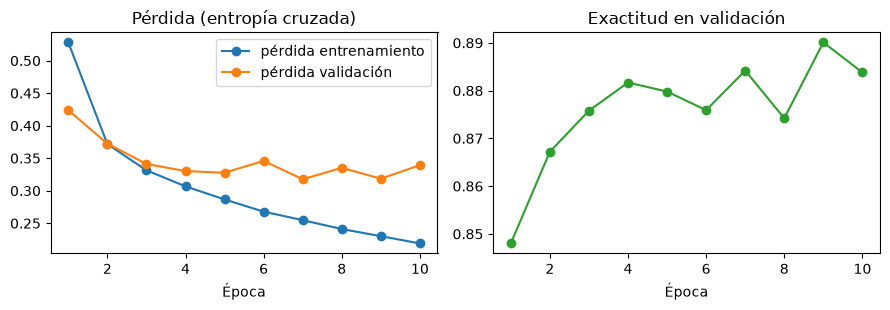

Test (una sola vez): pérdida 0.362, exactitud 0.877


In [4]:
def crear_mlp(ocultas=128, activacion=nn.ReLU):
    return nn.Sequential(nn.Linear(784, ocultas), activacion(), nn.Linear(ocultas, ocultas), activacion(), nn.Linear(ocultas, 10))

def evaluar(modelo, X_, y_):
    modelo.eval()                                      # modo evaluación (importa con dropout o normalización)
    with torch.no_grad():                              # no se guarda el grafo: más rápido y menos memoria
        logits = modelo(X_.to(device))
        return F.cross_entropy(logits, y_.to(device)).item(), (logits.argmax(1).cpu() == y_).float().mean().item()

def entrenar(modelo, optimizador, epocas=10, lote=128):
    modelo.to(device)
    cargador = DataLoader(TensorDataset(X_train, y_train), batch_size=lote, shuffle=True, generator=torch.Generator().manual_seed(42))
    historial = []
    for _ in range(epocas):
        modelo.train()
        perdida_total = 0.0
        for xb, yb in cargador:
            xb, yb = xb.to(device), yb.to(device)
            optimizador.zero_grad()                    # 1. borrar los gradientes del paso anterior
            perdida = F.cross_entropy(modelo(xb), yb)  # 2. pasada hacia delante + pérdida
            perdida.backward()                         # 3. retropropagación
            optimizador.step()                         # 4. actualizar los parámetros
            perdida_total += perdida.item() * len(xb)
        val_perdida, val_exactitud = evaluar(modelo, X_val, y_val)
        historial.append({"pérdida entrenamiento": perdida_total / len(X_train), "pérdida validación": val_perdida, "exactitud validación": val_exactitud})
    return pd.DataFrame(historial, index=range(1, epocas + 1))

torch.manual_seed(42)
mlp = crear_mlp()
print("Parámetros:", sum(p.numel() for p in mlp.parameters()))
hist = entrenar(mlp, torch.optim.Adam(mlp.parameters(), lr=1e-3))

fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
hist[["pérdida entrenamiento", "pérdida validación"]].plot(ax=axes[0], marker="o")
axes[0].set_title("Pérdida (entropía cruzada)"); axes[0].set_xlabel("Época")
hist["exactitud validación"].plot(ax=axes[1], marker="o", color="tab:green")
axes[1].set_title("Exactitud en validación"); axes[1].set_xlabel("Época")
plt.tight_layout()
plt.show()
test_perdida, test_exactitud = evaluar(mlp, X_test, y_test)
print(f"Test (una sola vez): pérdida {test_perdida:.3f}, exactitud {test_exactitud:.3f}")

El modelo tiene 118 282 parámetros, como en 2.3. La exactitud en validación sube rápido (0,85 tras la primera época) y se estabiliza entre 0,87 y 0,89 con altibajos. La pérdida de entrenamiento sigue bajando (de 0,53 a 0,22) mientras la de validación **deja de bajar hacia la época 4** (entre 0,32 y 0,35) y fluctúa: el modelo empieza a memorizar el entrenamiento (**sobreajuste**), y esa brecha es el motivo de las técnicas de [regularización y parada temprana](02-entrenamiento-y-regularizacion.ipynb). En test se obtiene una exactitud de 0,877.

### 3.4. La no linealidad: lo que aportan las capas ocultas

Comparamos tres modelos con el mismo optimizador y 5 épocas: (a) un modelo **lineal** sin capas ocultas (equivale a una regresión logística multinomial); (b) el mismo MLP de 3.3 pero con activación **identidad** (sin no linealidad); (c) el MLP con **ReLU**.

In [5]:
modelos = {
    "Lineal (sin capas ocultas)": nn.Linear(784, 10),
    "MLP sin no linealidad (identidad)": crear_mlp(activacion=nn.Identity),
    "MLP con ReLU": crear_mlp(),
}
filas = {}
for nombre, modelo in modelos.items():
    torch.manual_seed(42)
    for capa in modelo.modules():
        if isinstance(capa, nn.Linear):
            capa.reset_parameters()
    h = entrenar(modelo, torch.optim.Adam(modelo.parameters(), lr=1e-3), epocas=5)
    filas[nombre] = {"parámetros": sum(p.numel() for p in modelo.parameters()), "exactitud validación": h["exactitud validación"].iloc[-1],
                     "pérdida entrenamiento": h["pérdida entrenamiento"].iloc[-1]}
pd.DataFrame(filas).T.round(3)

,parámetros,exactitud validación,pérdida entrenamiento
Lineal (sin capas ocultas),7850.0,0.851,0.412
MLP sin no linealidad (identidad),118282.0,0.838,0.419
MLP con ReLU,118282.0,0.880,0.287


El MLP **sin no linealidad** tiene 118 282 parámetros (15 veces más que el lineal, 7 850) y **no lo mejora** (exactitud en validación de 0,838 frente a 0,851 y pérdida de entrenamiento de 0,419 frente a 0,412): apilar capas lineales no añade capacidad (2.2). Con **ReLU** la exactitud sube a 0,880 y la pérdida de entrenamiento baja a 0,287.

### 3.5. Optimizadores

Mismo MLP, mismas semillas y 5 épocas con SGD ($\eta=0{,}01$), SGD con momento ($\beta=0{,}9$) y Adam ($\eta=10^{-3}$).

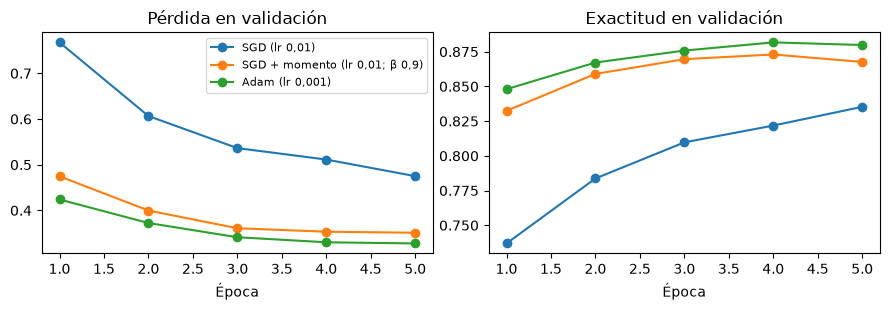

,pérdida validación,exactitud validación
"SGD (lr 0,01)",0.475,0.835
"SGD + momento (lr 0,01; β 0,9)",0.351,0.868
"Adam (lr 0,001)",0.328,0.880


In [6]:
optimizadores = {
    "SGD (lr 0,01)": lambda p: torch.optim.SGD(p, lr=0.01),
    "SGD + momento (lr 0,01; β 0,9)": lambda p: torch.optim.SGD(p, lr=0.01, momentum=0.9),
    "Adam (lr 0,001)": lambda p: torch.optim.Adam(p, lr=1e-3),
}
curvas = {}
for nombre, crear in optimizadores.items():
    torch.manual_seed(42)
    modelo = crear_mlp()
    curvas[nombre] = entrenar(modelo, crear(modelo.parameters()), epocas=5)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
for nombre, h in curvas.items():
    h["pérdida validación"].plot(ax=axes[0], marker="o", label=nombre)
    h["exactitud validación"].plot(ax=axes[1], marker="o", label=nombre)
axes[0].set_title("Pérdida en validación"); axes[1].set_title("Exactitud en validación")
for ax in axes:
    ax.set_xlabel("Época")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()
pd.DataFrame({n: h.iloc[-1] for n, h in curvas.items()}).T[["pérdida validación", "exactitud validación"]].round(3)

Con el mismo número de épocas, SGD simple es el más lento (exactitud en validación de 0,835), el momento acelera mucho (0,868) y Adam llega más lejos (0,880). No quiere decir que SGD sea peor en general (con más épocas o una tasa mayor se acerca), sino que Adam necesita menos ajuste de la tasa de aprendizaje.

### 3.6. La tasa de aprendizaje

Es el hiperparámetro más sensible. Probamos SGD con cuatro valores y 3 épocas.

In [7]:
filas = {}
for lr in [1e-4, 1e-3, 1e-1, 1.0]:
    torch.manual_seed(42)
    modelo = crear_mlp()
    h = entrenar(modelo, torch.optim.SGD(modelo.parameters(), lr=lr), epocas=3)
    filas[f"lr = {lr}"] = {"pérdida entrenamiento (época 3)": h["pérdida entrenamiento"].iloc[-1], "exactitud validación": h["exactitud validación"].iloc[-1]}
pd.DataFrame(filas).T.round(3)

,pérdida entrenamiento (época 3),exactitud validación
lr = 0.0001,2.260,0.168
lr = 0.001,1.633,0.600
lr = 0.1,0.374,0.855
lr = 1.0,NaN,0.107


Con $\eta=10^{-4}$ la red apenas se mueve en 3 épocas (pérdida de 2,26, casi el valor inicial de $\ln10\approx2{,}30$ de un modelo que reparte probabilidad uniforme); con $10^{-3}$ avanza despacio; con $0{,}1$ aprende bien; y con $1{,}0$ los pasos son tan grandes que la pérdida **diverge a `nan`** y la exactitud cae al azar (≈ 0,1). Una tasa demasiado baja desperdicia tiempo, una demasiado alta no converge: se explora en escala logarítmica.

### 3.7. El gradiente que desaparece

Construimos redes de 10 capas ocultas de 64 neuronas con distintas activaciones, calculamos la pérdida de un lote de 256 imágenes y medimos la **norma del gradiente de los pesos de cada capa** (de la entrada a la salida), antes de entrenar.

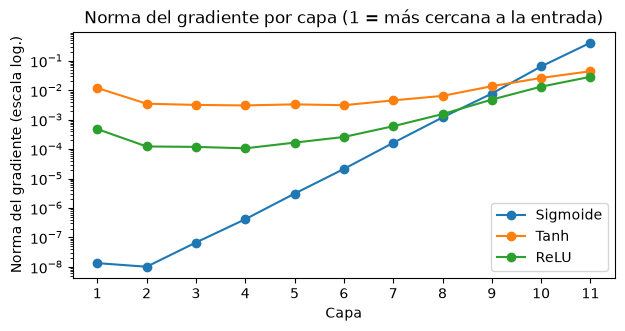

Sigmoide    3.1e+07
Tanh        3.7e+00
ReLU        6.0e+01


In [8]:
def normas_gradiente(activacion, profundidad=10, ancho=64):
    torch.manual_seed(0)
    capas, n_in = [], 784
    for _ in range(profundidad):
        capas += [nn.Linear(n_in, ancho), activacion()]
        n_in = ancho
    red = nn.Sequential(*capas, nn.Linear(ancho, 10))
    F.cross_entropy(red(X_train[:256]), y_train[:256]).backward()
    return [c.weight.grad.norm().item() for c in red if isinstance(c, nn.Linear)]

normas = pd.DataFrame({nombre: normas_gradiente(act) for nombre, act in [("Sigmoide", nn.Sigmoid), ("Tanh", nn.Tanh), ("ReLU", nn.ReLU)]},
                      index=[f"capa {i}" for i in range(1, 12)])
fig, ax = plt.subplots(figsize=(7, 3.2))
normas.plot(ax=ax, marker="o", logy=True)
ax.set_title("Norma del gradiente por capa (1 = más cercana a la entrada)")
ax.set_xticks(range(11)); ax.set_xticklabels(range(1, 12))
ax.set_xlabel("Capa"); ax.set_ylabel("Norma del gradiente (escala log.)")
plt.show()
print((normas.iloc[-1] / normas.iloc[0]).rename("gradiente de la última capa / gradiente de la primera").map("{:.1e}".format).to_string())

Con la **sigmoide**, el gradiente de la capa más cercana a la entrada es unas **$3\cdot10^{7}$ veces menor** que el de la salida (de $4\cdot10^{-1}$ a $10^{-8}$): las primeras capas no aprenden en la práctica. Con **tanh** la diferencia es de un factor 3,7 y con **ReLU**, de 60: se atenúa mucho menos (con la inicialización por defecto de PyTorch, que no está pensada específicamente para la ReLU). Es una de las razones por las que la ReLU sustituyó a la sigmoide en las capas ocultas.

## 4. Parámetros importantes y errores comunes

### 4.1. Parámetros que conviene conocer

| Parámetro | Qué controla | Valores típicos / consejo |
|---|---|---|
| **Tamaño y número de capas ocultas** | Capacidad de la red | Empieza pequeña (1–3 capas, 64–512 neuronas) y aumenta si hay **subajuste**; más capacidad con pocos datos sobreajusta |
| **Activación** | No linealidad de las capas ocultas | ReLU por defecto; la salida depende de la tarea (sin activación para regresión, logits para clasificación) |
| **Optimizador** | Cómo se actualizan los pesos | Adam para empezar; SGD con momento si se busca ajustar al máximo |
| **Tasa de aprendizaje** $\eta$ | Tamaño del paso | `1e-3` con Adam; `1e-2`–`1e-1` con SGD; búscala en escala logarítmica (3.6) |
| **Tamaño del lote** | Ruido del gradiente y coste por iteración | 32–256; lotes grandes son más rápidos por época pero suelen exigir subir la tasa |
| **Épocas** | Cuánto se entrena | Las que haga falta hasta que la validación deje de mejorar ([parada temprana](02-entrenamiento-y-regularizacion.ipynb)) |
| **Semilla** (`torch.manual_seed`) | Reproducibilidad | Fíjala y recuerda que con GPU algunos resultados pueden diferir ligeramente |

### 4.2. Errores comunes

- **Olvidar `optimizador.zero_grad()`.** PyTorch **acumula** los gradientes; sin borrarlos, cada paso usa la suma de todos los anteriores. Lo vemos a continuación.
- **Aplicar softmax antes de `cross_entropy`.** La pérdida de PyTorch espera *logits*; si ya le pasas probabilidades, calcula la softmax dos veces: aplasta las diferencias y la pérdida no puede bajar de un valor mínimo. Demo siguiente.
- **Evaluar sin `model.eval()` y `torch.no_grad()`.** Con capas como *dropout* o normalización por lotes el resultado cambia en evaluación, y sin `no_grad` se gasta memoria guardando un grafo que no se usa.
- **No normalizar las entradas.** Con variables en escalas muy distintas, el gradiente se dispara en unas direcciones y se atenúa en otras y el entrenamiento se vuelve lento o inestable ([escalado](../03-preparacion-datos/03-transformacion-datos.ipynb)).
- **Tasa de aprendizaje mal elegida** (3.6): diverge (`nan`) o no avanza. Si la pérdida inicial no baja o se vuelve `nan`, lo primero que se prueba es dividir o multiplicar $\eta$ por 10.
- **Decidir con el test.** Elegir épocas o arquitectura mirando el test lo contamina; para eso está la validación ([flujo de ML](../04-machine-learning/01-flujo-ml-y-evaluacion.ipynb)). Aquí el test se mira una vez.
- **No mirar la curva de validación.** La exactitud final esconde el sobreajuste que se ve en 3.3 (pérdida de entrenamiento 0,22 frente a 0,34 en validación).
- **Usar una red densa con imágenes grandes.** Una red densa no aprovecha que los píxeles vecinos están relacionados y sus parámetros crecen con el tamaño de la imagen. En una práctica con imágenes de satélite de 21 clases (reducidas a $32\times32\times3$, 3 072 entradas), un perceptrón con 3,2 millones de parámetros alcanzó una exactitud de 0,23 en test, mientras que una red convolucional de 112 mil parámetros llegó a 0,87. Con las imágenes sin reducir ($224\times224\times3=150\,528$ entradas) solo la primera capa de 1 024 neuronas tendría unos 154 millones de parámetros. Es la motivación de las [redes convolucionales](03-redes-convolucionales.ipynb).

#### Demo: gradientes que se acumulan y doble softmax

In [9]:
w = torch.tensor([1.0], requires_grad=True)
for paso in range(1, 4):
    (3 * w).sum().backward()                           # dL/dw = 3 en cada paso
    print(f"paso {paso} sin zero_grad: w.grad = {w.grad.item():.0f}  (debería ser 3)")

logits = torch.tensor([[10.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]])
clase = torch.tensor([0])
print(f"\nCross-entropy con logits (correcto):      {F.cross_entropy(logits, clase).item():.5f}")
print(f"Cross-entropy sobre softmax (doble softmax): {F.cross_entropy(logits.softmax(1), clase).item():.5f}  <- no baja de ≈ 1,46 ni con la predicción perfecta")

paso 1 sin zero_grad: w.grad = 3  (debería ser 3)
paso 2 sin zero_grad: w.grad = 6  (debería ser 3)
paso 3 sin zero_grad: w.grad = 9  (debería ser 3)

Cross-entropy con logits (correcto):      0.00041
Cross-entropy sobre softmax (doble softmax): 1.46150  <- no baja de ≈ 1,46 ni con la predicción perfecta


Sin `zero_grad` el gradiente que "ve" el optimizador es 3, 6, 9… en lugar de 3. Y con una predicción casi perfecta (probabilidad de la clase correcta ≈ 1) la pérdida correcta es ≈ 0, pero con doble softmax es de 1,46: nunca puede bajar de ese valor, así que el modelo sigue "aprendiendo" para nada.

## 5. Comparación con métodos relacionados

| Modelo | Capacidad | Datos que necesita | Ajuste | Cuándo usarlo |
|---|---|---|---|---|
| **Regresión logística / lineal** | Solo fronteras lineales | Pocos | Mínimo | Referencia (*baseline*) y cuando importa explicar los coeficientes |
| **Árboles / [Random Forest](../04-machine-learning/10-bagging-y-random-forest.ipynb) / [boosting](../04-machine-learning/11-boosting.ipynb)** | Interacciones y no linealidades en datos tabulares | Pocos a muchos | Poco (RF) a medio (boosting) | Primera opción con datos tabulares |
| **Red densa (MLP)** | Función no lineal muy flexible | Muchos, mejor si los datos están en escalas comparables | Alto (arquitectura, tasa, épocas) | Tabular con muchos datos o como bloque de redes más grandes |
| **[Red convolucional](03-redes-convolucionales.ipynb)** | Como la densa, aprovechando la estructura espacial | Muchos | Alto | Imágenes |
| **[Redes recurrentes y *transformers*](06-redes-recurrentes.ipynb)** | Estructura secuencial | Muchos | Alto | Series temporales, texto |

Una red densa es un modelo más y debe batir a una línea base sencilla (3.4: el modelo lineal ya da ≈ 0,85 en este problema, y el MLP con ReLU sube a 0,88). Con datos tabulares y pocas filas, un bosque o un *boosting* suelen ganarle con menos esfuerzo; las redes se justifican cuando hay muchos datos o cuando la estructura de los datos (imagen, secuencia) pide una arquitectura específica.

## 6. Referencias

### Fuentes

- Xiao, H., Rasul, K. y Vollgraf, R. (2017). *Fashion-MNIST: a novel image dataset for benchmarking machine learning algorithms*. arXiv:1708.07747. Origen del conjunto de datos, descargado con [`torchvision.datasets.FashionMNIST`](https://pytorch.org/vision/stable/generated/torchvision.datasets.FashionMNIST.html).
- PyTorch: [*Learn the Basics*](https://pytorch.org/tutorials/beginner/basics/intro.html), [`torch.nn`](https://pytorch.org/docs/stable/nn.html), [`torch.optim`](https://pytorch.org/docs/stable/optim.html), [`CrossEntropyLoss`](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html) y [*Autograd mechanics*](https://pytorch.org/docs/stable/notes/autograd.html).

### Para saber más

- Goodfellow, I., Bengio, Y. y Courville, A. (2016). [*Deep Learning*](https://www.deeplearningbook.org/). MIT Press. El libro de referencia; el capítulo 6 (redes de propagación hacia delante) y el 8 (optimización) cubren este notebook.
- Zhang, A., Lipton, Z. C., Li, M. y Smola, A. J. (2023). [*Dive into Deep Learning*](https://d2l.ai/). Cambridge University Press. Libro libre con código ejecutable; sus capítulos sobre perceptrones multicapa y optimización amplían este notebook.